In [74]:
import numpy as ap
import pandas as pd
!pip install requests

In [75]:
import requests

In [157]:
import requests

url = "https://api.worldbank.org/v2/country?per_page=300&format=json"

response = requests.get(url)

print(response.status_code)
print(response.headers["Content-Type"])
data = response.json()

print(data[1][:5])  # first 5 countries


200
application/json;charset=utf-8
[{'id': 'ABW', 'iso2Code': 'AW', 'name': 'Aruba', 'region': {'id': 'LCN', 'iso2code': 'ZJ', 'value': 'Latin America & Caribbean '}, 'adminregion': {'id': '', 'iso2code': '', 'value': ''}, 'incomeLevel': {'id': 'HIC', 'iso2code': 'XD', 'value': 'High income'}, 'lendingType': {'id': 'LNX', 'iso2code': 'XX', 'value': 'Not classified'}, 'capitalCity': 'Oranjestad', 'longitude': '-70.0167', 'latitude': '12.5167'}, {'id': 'AFE', 'iso2Code': 'ZH', 'name': 'Africa Eastern and Southern', 'region': {'id': 'NA', 'iso2code': 'NA', 'value': 'Aggregates'}, 'adminregion': {'id': '', 'iso2code': '', 'value': ''}, 'incomeLevel': {'id': 'NA', 'iso2code': 'NA', 'value': 'Aggregates'}, 'lendingType': {'id': '', 'iso2code': '', 'value': 'Aggregates'}, 'capitalCity': '', 'longitude': '', 'latitude': ''}, {'id': 'AFG', 'iso2Code': 'AF', 'name': 'Afghanistan', 'region': {'id': 'MEA', 'iso2code': 'ZQ', 'value': 'Middle East, North Africa, Afghanistan & Pakistan'}, 'adminregio

In [108]:
print(data[0])
print(len(data))

#  1 --> Meta data
# 2 --> Actual data

{'page': 1, 'pages': 1, 'per_page': '300', 'total': 296}
2


In [110]:
countries = data[1]
countries = pd.DataFrame(countries)


In [112]:
countries

,id,iso2Code,name,region,adminregion,incomeLevel,lendingType,capitalCity,longitude,latitude
0,ABW,AW,Aruba,"{'id': 'LCN', 'iso2code': 'ZJ', 'value': 'Lati...","{'id': '', 'iso2code': '', 'value': ''}","{'id': 'HIC', 'iso2code': 'XD', 'value': 'High...","{'id': 'LNX', 'iso2code': 'XX', 'value': 'Not ...",Oranjestad,-70.0167,12.5167
1,AFE,ZH,Africa Eastern and Southern,"{'id': 'NA', 'iso2code': 'NA', 'value': 'Aggre...","{'id': '', 'iso2code': '', 'value': ''}","{'id': 'NA', 'iso2code': 'NA', 'value': 'Aggre...","{'id': '', 'iso2code': '', 'value': 'Aggregates'}",,,
2,AFG,AF,Afghanistan,"{'id': 'MEA', 'iso2code': 'ZQ', 'value': 'Midd...","{'id': 'MNA', 'iso2code': 'XQ', 'value': 'Midd...","{'id': 'LIC', 'iso2code': 'XM', 'value': 'Low ...","{'id': 'IDX', 'iso2code': 'XI', 'value': 'IDA'}",Kabul,69.1761,34.5228
3,AFR,A9,Africa,"{'id': 'NA', 'iso2code': 'NA', 'value': 'Aggre...","{'id': '', 'iso2code': '', 'value': ''}","{'id': 'NA', 'iso2code': 'NA', 'value': 'Aggre...","{'id': '', 'iso2code': '', 'value': 'Aggregates'}",,,
4,AFW,ZI,Africa Western and Central,"{'id': 'NA', 'iso2code': 'NA', 'value': 'Aggre...","{'id': '', 'iso2code': '', 'value': ''}","{'id': 'NA', 'iso2code': 'NA', 'value': 'Aggre...","{'id': '', 'iso2code': '', 'value': 'Aggregates'}",,,
...,...,...,...,...,...,...,...,...,...,...
291,XZN,A5,Sub-Saharan Africa excluding South Africa and ...,"{'id': 'NA', 'iso2code': 'NA', 'value': 'Aggre...","{'id': '', 'iso2code': '', 'value': ''}","{'id': 'NA', 'iso2code': 'NA', 'value': 'Aggre...","{'id': '', 'iso2code': '', 'value': 'Aggregates'}",,,
292,YEM,YE,"Yemen, Rep.","{'id': 'MEA', 'iso2code': 'ZQ', 'value': 'Midd...","{'id': 'MNA', 'iso2code': 'XQ', 'value': 'Midd...","{'id': 'LIC', 'iso2code': 'XM', 'value': 'Low ...","{'id': 'IDX', 'iso2code': 'XI', 'value': 'IDA'}",Sana'a,44.2075,15.352
293,ZAF,ZA,South Africa,"{'id': 'SSF', 'iso2code': 'ZG', 'value': 'Sub-...","{'id': 'SSA', 'iso2code': 'ZF', 'value': 'Sub-...","{'id': 'UMC', 'iso2code': 'XT', 'value': 'Uppe...","{'id': 'IBD', 'iso2code': 'XF', 'value': 'IBRD'}",Pretoria,28.1871,-25.746
294,ZMB,ZM,Zambia,"{'id': 'SSF', 'iso2code': 'ZG', 'value': 'Sub-...","{'id': 'SSA', 'iso2code': 'ZF', 'value': 'Sub-...","{'id': 'LMC', 'iso2code': 'XN', 'value': 'Lowe...","{'id': 'IDX', 'iso2code': 'XI', 'value': 'IDA'}",Lusaka,28.2937,-15.3982


In [18]:
countries["incomeLevel"][1]

{'id': 'NA', 'iso2code': 'NA', 'value': 'Aggregates'}

In [19]:
countries["region"] = countries["region"].apply(lambda x:x["value"])

In [20]:
countries["incomeLevel"] = countries["incomeLevel"].apply(lambda x:x["value"])

In [21]:
countries["lendingType"] = countries["lendingType"].apply(lambda x:x["value"])

In [22]:
countries.drop(columns=["adminregion" , "capitalCity" , "lendingType"], inplace = True)

In [118]:
countries

,id,iso2Code,name,region,incomeLevel,longitude,latitude
0,ABW,AW,Aruba,Latin America & Caribbean,High income,-70.0167,12.5167
1,AFE,ZH,Africa Eastern and Southern,Aggregates,Aggregates,,
2,AFG,AF,Afghanistan,"Middle East, North Africa, Afghanistan & Pakistan",Low income,69.1761,34.5228
3,AFR,A9,Africa,Aggregates,Aggregates,,
4,AFW,ZI,Africa Western and Central,Aggregates,Aggregates,,
...,...,...,...,...,...,...,...
291,XZN,A5,Sub-Saharan Africa excluding South Africa and ...,Aggregates,Aggregates,,
292,YEM,YE,"Yemen, Rep.","Middle East, North Africa, Afghanistan & Pakistan",Low income,44.2075,15.352
293,ZAF,ZA,South Africa,Sub-Saharan Africa,Upper middle income,28.1871,-25.746
294,ZMB,ZM,Zambia,Sub-Saharan Africa,Lower middle income,28.2937,-15.3982


In [23]:
countries.rename(columns ={"iso2Code":"country_id"}, inplace=True)

In [24]:
countries[countries["region"] == "Aggregates"]	

,id,country_id,name,region,incomeLevel,longitude,latitude
1,AFE,ZH,Africa Eastern and Southern,Aggregates,Aggregates,,
3,AFR,A9,Africa,Aggregates,Aggregates,,
4,AFW,ZI,Africa Western and Central,Aggregates,Aggregates,,
8,ARB,1A,Arab World,Aggregates,Aggregates,,
18,BEA,B4,East Asia & Pacific (IBRD-only countries),Aggregates,Aggregates,,
...,...,...,...,...,...,...,...
269,TSA,T5,South Asia (IDA & IBRD),Aggregates,Aggregates,,
270,TSS,T6,Sub-Saharan Africa (IDA & IBRD countries),Aggregates,Aggregates,,
278,UMC,XT,Upper middle income,Aggregates,Aggregates,,
288,WLD,1W,World,Aggregates,Aggregates,,


In [ ]:
# code for indicator
base_url = "https://api.worldbank.org/v2/indicator?format=json&per_page=50"
response = requests.get(base_url)
response.status_code

In [127]:
data = response.json()

In [128]:
data[0]

{'page': 1, 'pages': 587, 'per_page': '50', 'total': 29323}

In [ ]:
pd.DataFrame(data[1])

In [140]:
all_dfs = []
for i in range(1 , 588):
    url = f"https://api.worldbank.org/v2/indicator?format=json&per_page=500&page={i}"
    response = requests.get(url)
    
    if response.status_code == 200:
      data = response.json()

      if len(data)<2 or data[1] is None:
          print(f"No data at page{i}")
          continue

      indicators = data[1]
      df = pd.DataFrame([{"id":item["id"] ,
                          "name":item["name"]} for item in indicators])
      all_dfs.append(df)
      print(f"Page{i}: {len(df)} indicators collector")
    else:
        print(f"Failed to fetch page {i} , status code {response.status_code}")

Page1: 500 indicators collector
Page2: 500 indicators collector
Page3: 500 indicators collector
Page4: 500 indicators collector
Page5: 500 indicators collector
Page6: 500 indicators collector
Page7: 500 indicators collector
Page8: 500 indicators collector
Page9: 500 indicators collector
Page10: 500 indicators collector
Page11: 500 indicators collector
Page12: 500 indicators collector
Page13: 500 indicators collector
Page14: 500 indicators collector
Page15: 500 indicators collector
Page16: 500 indicators collector
Page17: 500 indicators collector
Page18: 500 indicators collector
Page19: 500 indicators collector
Page20: 500 indicators collector
Page21: 500 indicators collector
Page22: 500 indicators collector
Page23: 500 indicators collector
Page24: 500 indicators collector
Page25: 500 indicators collector
Page26: 500 indicators collector
Page27: 500 indicators collector
Page28: 500 indicators collector
Page29: 500 indicators collector
Page30: 500 indicators collector
Page31: 500 indicat

ConnectionError: ('Connection aborted.', ConnectionResetError(10054, 'An existing connection was forcibly closed by the remote host', None, 10054, None))

In [81]:
#data - 0 ,1
# metadata
# actual data

In [141]:
import requests
import pandas as pd

base_url = "https://api.worldbank.org/v2/indicator"
params = {
    "format": "json",
    "per_page": 500,
    "page": 1
}

response = requests.get(base_url, params=params)
data = response.json()

total_pages = data[0]["pages"]
print("Total pages:", total_pages)


Total pages: 59


In [136]:
all_dfs = []

for i in range(1, total_pages + 1):
    params["page"] = i
    response = requests.get(base_url, params=params)
    data = response.json()

    indicators = data[1]

    df = pd.DataFrame([
        {
            "id": item["id"],
            "name": item["name"]
        }
        for item in indicators
    ])

    all_dfs.append(df)
    print(f"Page {i}: {len(df)} indicators collected")


Page 1: 500 indicators collected
Page 2: 500 indicators collected
Page 3: 500 indicators collected
Page 4: 500 indicators collected
Page 5: 500 indicators collected
Page 6: 500 indicators collected
Page 7: 500 indicators collected
Page 8: 500 indicators collected
Page 9: 500 indicators collected
Page 10: 500 indicators collected
Page 11: 500 indicators collected
Page 12: 500 indicators collected
Page 13: 500 indicators collected
Page 14: 500 indicators collected
Page 15: 500 indicators collected
Page 16: 500 indicators collected
Page 17: 500 indicators collected
Page 18: 500 indicators collected
Page 19: 500 indicators collected
Page 20: 500 indicators collected
Page 21: 500 indicators collected
Page 22: 500 indicators collected
Page 23: 500 indicators collected
Page 24: 500 indicators collected
Page 25: 500 indicators collected
Page 26: 500 indicators collected
Page 27: 500 indicators collected
Page 28: 500 indicators collected
Page 29: 500 indicators collected
Page 30: 500 indicators

In [142]:
final_df = pd.concat(all_dfs, ignore_index=True)
print(final_df.shape)
 

(29323, 2)


In [25]:
final_df.to_csv("final_df.csv")

In [ ]:
#extrect value from various indictors under the domain for each country


In [11]:
indicatore_groups = {
    "economic_activity_growth":["NY.GDP.MKTP.Kd.ZG","NY.GDP.PCAP.CD"],
    "labour_market_indicators":["SL.UEM.TOTL.ZS","SL.UEM.1524.ZS","SL.TLF.TOTL.IN"],
    "trade_globalization":["NE.EXP.GNFS.CD" , "NE.TLF.TOTL.IN"],
    "poverty_inequality":["SI.POV.NAHC", "SI.POV.GINI"],
    "environmental_indicators":["EG.FEC.RNEW.ZS" , "AG.LND.FRST.ZS"],
    "health_indicators" :["SP.DYN.LE00.IN" , "SP.DYN.IMRT.IN", "SH.H2O.BASW.ZS" , "SH.XPD.CHEX..GD.ZS" , "SH.IMM.IDPT" , "SH.IMM.MEAS" , "SH.MMR.RISK.ZS" , 
                          "SH.DTH.COMM.ZS" , "SH.TBS.INCD", "SH.STA.BRTC.ZS" , "SH.STA.MART" , "SH.POP.6SUP.TO.ZS" , "SH.HIV.INCD.ZS"] , 
    "technology_indicators" : ["IT.NET.USER.ZS" , "IT.CEL.SETS.P2"]}
    

In [ ]:
base_url= requests.get("https://api.worldbank.org/countries/all/indicators/{}?format=json&per_page= 1000&page={}")

In [12]:
import time
base_url = (
    "https://api.worldbank.org/v2/country/all/indicator/{}"
    "?format=json&per_page=1000&page={}&date=2016:2023"
)



category_dataframes = {}
for category,indicators in indicatore_groups.items():
    print(f"Fetch information for category : {category}")
    all_dfs_for_category = []

    for indicator_code in indicators:
        print(f"Fetching indicator: {indicator_code}")
        page=1

        while True:
            url = base_url.format(indicator_code , page)
            response = requests.get(url)
            if response.status_code!=200:
                print(f"No data for indicator{indicator_code}on page {page}")
            try:
                 data = response.json()
            except ValueError:
                 print(f"Invalid JSON for {indicator_code} at page {page}")
                 break
            if len(data) < 2 or data[1] is None:
               print(f"No records for {indicator_code} at page {page}")
               break


            total_pages = data[0]["pages"]
            record = data[1]

            df = pd.json_normalize(record)
            df = df[[
                "country.id","country.value","indicator.id","indicator.value" , "date" , "value"]].rename(columns={"country.id":"country_id",
                                                                                                                   "country.value":"country_value",
                                                                                                                   "indicator.id":"indicator_id",
                                                                                                                   "indicator.value":"indicator_name",
                                                                                                                  "date":"year"})
            df = df[df["year"].astype(int)>2015]
            all_dfs_for_category.append(df)

            if page>=total_pages:
                break
            else:
                page += 1
                time.sleep(0.3)


        if all_dfs_for_category:
            combine_df = pd.concat(all_dfs_for_category , ignore_index = True)
            category_dataframes[category]=combine_df
            print(f"Total row collectes for  {category} :{len(combine_df)}")
        else:
            print(f"No data collected for {category}")

print("Data Fecthing Completed")            
                                  



Fetch information for category : economic_activity_growth
Fetching indicator: NY.GDP.MKTP.Kd.ZG
Total row collectes for  economic_activity_growth :2128
Fetching indicator: NY.GDP.PCAP.CD
Total row collectes for  economic_activity_growth :4256
Fetch information for category : labour_market_indicators
Fetching indicator: SL.UEM.TOTL.ZS
Total row collectes for  labour_market_indicators :2128
Fetching indicator: SL.UEM.1524.ZS
Total row collectes for  labour_market_indicators :4256
Fetching indicator: SL.TLF.TOTL.IN
Total row collectes for  labour_market_indicators :6384
Fetch information for category : trade_globalization
Fetching indicator: NE.EXP.GNFS.CD
Total row collectes for  trade_globalization :2128
Fetching indicator: NE.TLF.TOTL.IN
No records for NE.TLF.TOTL.IN at page 1
Total row collectes for  trade_globalization :2128
Fetch information for category : poverty_inequality
Fetching indicator: SI.POV.NAHC
Total row collectes for  poverty_inequality :2128
Fetching indicator: SI.POV.

ConnectionError: ('Connection aborted.', ConnectionAbortedError(10053, 'An established connection was aborted by the software in your host machine', None, 10053, None))

In [42]:
response = requests.get(base_url)

In [44]:
response.json()[0]

{'page': 1,
 'pages': 346,
 'per_page': 50,
 'total': 17290,
 'sourceid': '2',
 'lastupdated': '2025-12-19'}

In [26]:
economic_activity= category_dataframes.get("economic_activity_growth" ,pd.DataFrame())
labour_market_jobs = category_dataframes.get("labour_market_indicators" ,pd.DataFrame())
trade_globalization= category_dataframes.get("trade_globalization" ,pd.DataFrame())
poverty_inequality = category_dataframes.get("poverty_inequality" ,pd.DataFrame())
environmental_indicators = category_dataframes.get("environmental_indicators" ,pd.DataFrame())
health_indicators= category_dataframes.get("health_indicators" ,pd.DataFrame())
technology_indicator = category_dataframes.get("technology_indicators" ,pd.DataFrame())


In [25]:
economic = pd.merge(economic_activity , countries , on ="country_id" , how="inner")
labour_market = pd.merge(labour_market_jobs , countries , on ="country_id" , how="inner")
trade = pd.merge(trade_globalization , countries , on ="country_id" , how="inner")
poverty = pd.merge(poverty_inequality , countries , on ="country_id" , how="inner")
environment = pd.merge(environmental_indicators , countries , on ="country_id" , how="inner")
health =pd.merge(health_indicators, countries , on ="country_id" , how="inner")
technology =pd.merge(technology_indicator , countries , on ="country_id" , how="inner")

In [27]:
economic.drop(columns=["indicator_id" , "name" , "id"],inplace=True)
labour_market.drop(columns=["indicator_id" , "name" , "id"],inplace=True)
trade.drop(columns=["indicator_id" , "name" , "id"],inplace=True)
poverty.drop(columns=["indicator_id" , "name" , "id"],inplace=True)
environment.drop(columns=["indicator_id" , "name" , "id"],inplace=True)
health.drop(columns=["indicator_id" , "name" , "id"],inplace=True)
technology.drop(columns=["indicator_id" , "name" , "id"],inplace=True)

In [28]:
health

,country_id,country_value,indicator_name,year,value,region,incomeLevel,longitude,latitude
0,ZH,Africa Eastern and Southern,"Life expectancy at birth, total (years)",2023,65.146154,Aggregates,Aggregates,,
1,ZH,Africa Eastern and Southern,"Life expectancy at birth, total (years)",2022,64.487020,Aggregates,Aggregates,,
2,ZH,Africa Eastern and Southern,"Life expectancy at birth, total (years)",2021,62.979999,Aggregates,Aggregates,,
3,ZH,Africa Eastern and Southern,"Life expectancy at birth, total (years)",2020,63.766484,Aggregates,Aggregates,,
4,ZH,Africa Eastern and Southern,"Life expectancy at birth, total (years)",2019,63.857261,Aggregates,Aggregates,,
...,...,...,...,...,...,...,...,...,...
21019,ZW,Zimbabwe,"Incidence of HIV, ages 15-49 (per 1,000 uninfe...",2020,1.900000,Sub-Saharan Africa,Lower middle income,31.0672,-17.8312
21020,ZW,Zimbabwe,"Incidence of HIV, ages 15-49 (per 1,000 uninfe...",2019,2.300000,Sub-Saharan Africa,Lower middle income,31.0672,-17.8312
21021,ZW,Zimbabwe,"Incidence of HIV, ages 15-49 (per 1,000 uninfe...",2018,2.700000,Sub-Saharan Africa,Lower middle income,31.0672,-17.8312
21022,ZW,Zimbabwe,"Incidence of HIV, ages 15-49 (per 1,000 uninfe...",2017,3.600000,Sub-Saharan Africa,Lower middle income,31.0672,-17.8312


In [30]:
df_wide = health.pivot_table(index=["country_value","year"],
                             columns="indicator_name",
                             values="value"
                            )

In [149]:
economic.to_csv("economic.csv")
labour_market.to_csv("labour_market.csv")
trade.to_csv("trade.csv")
poverty.to_csv("poverty.csv")
environment.to_csv("environment.csv")
health.to_csv("health.csv")
technology.to_csv("technology.csv")

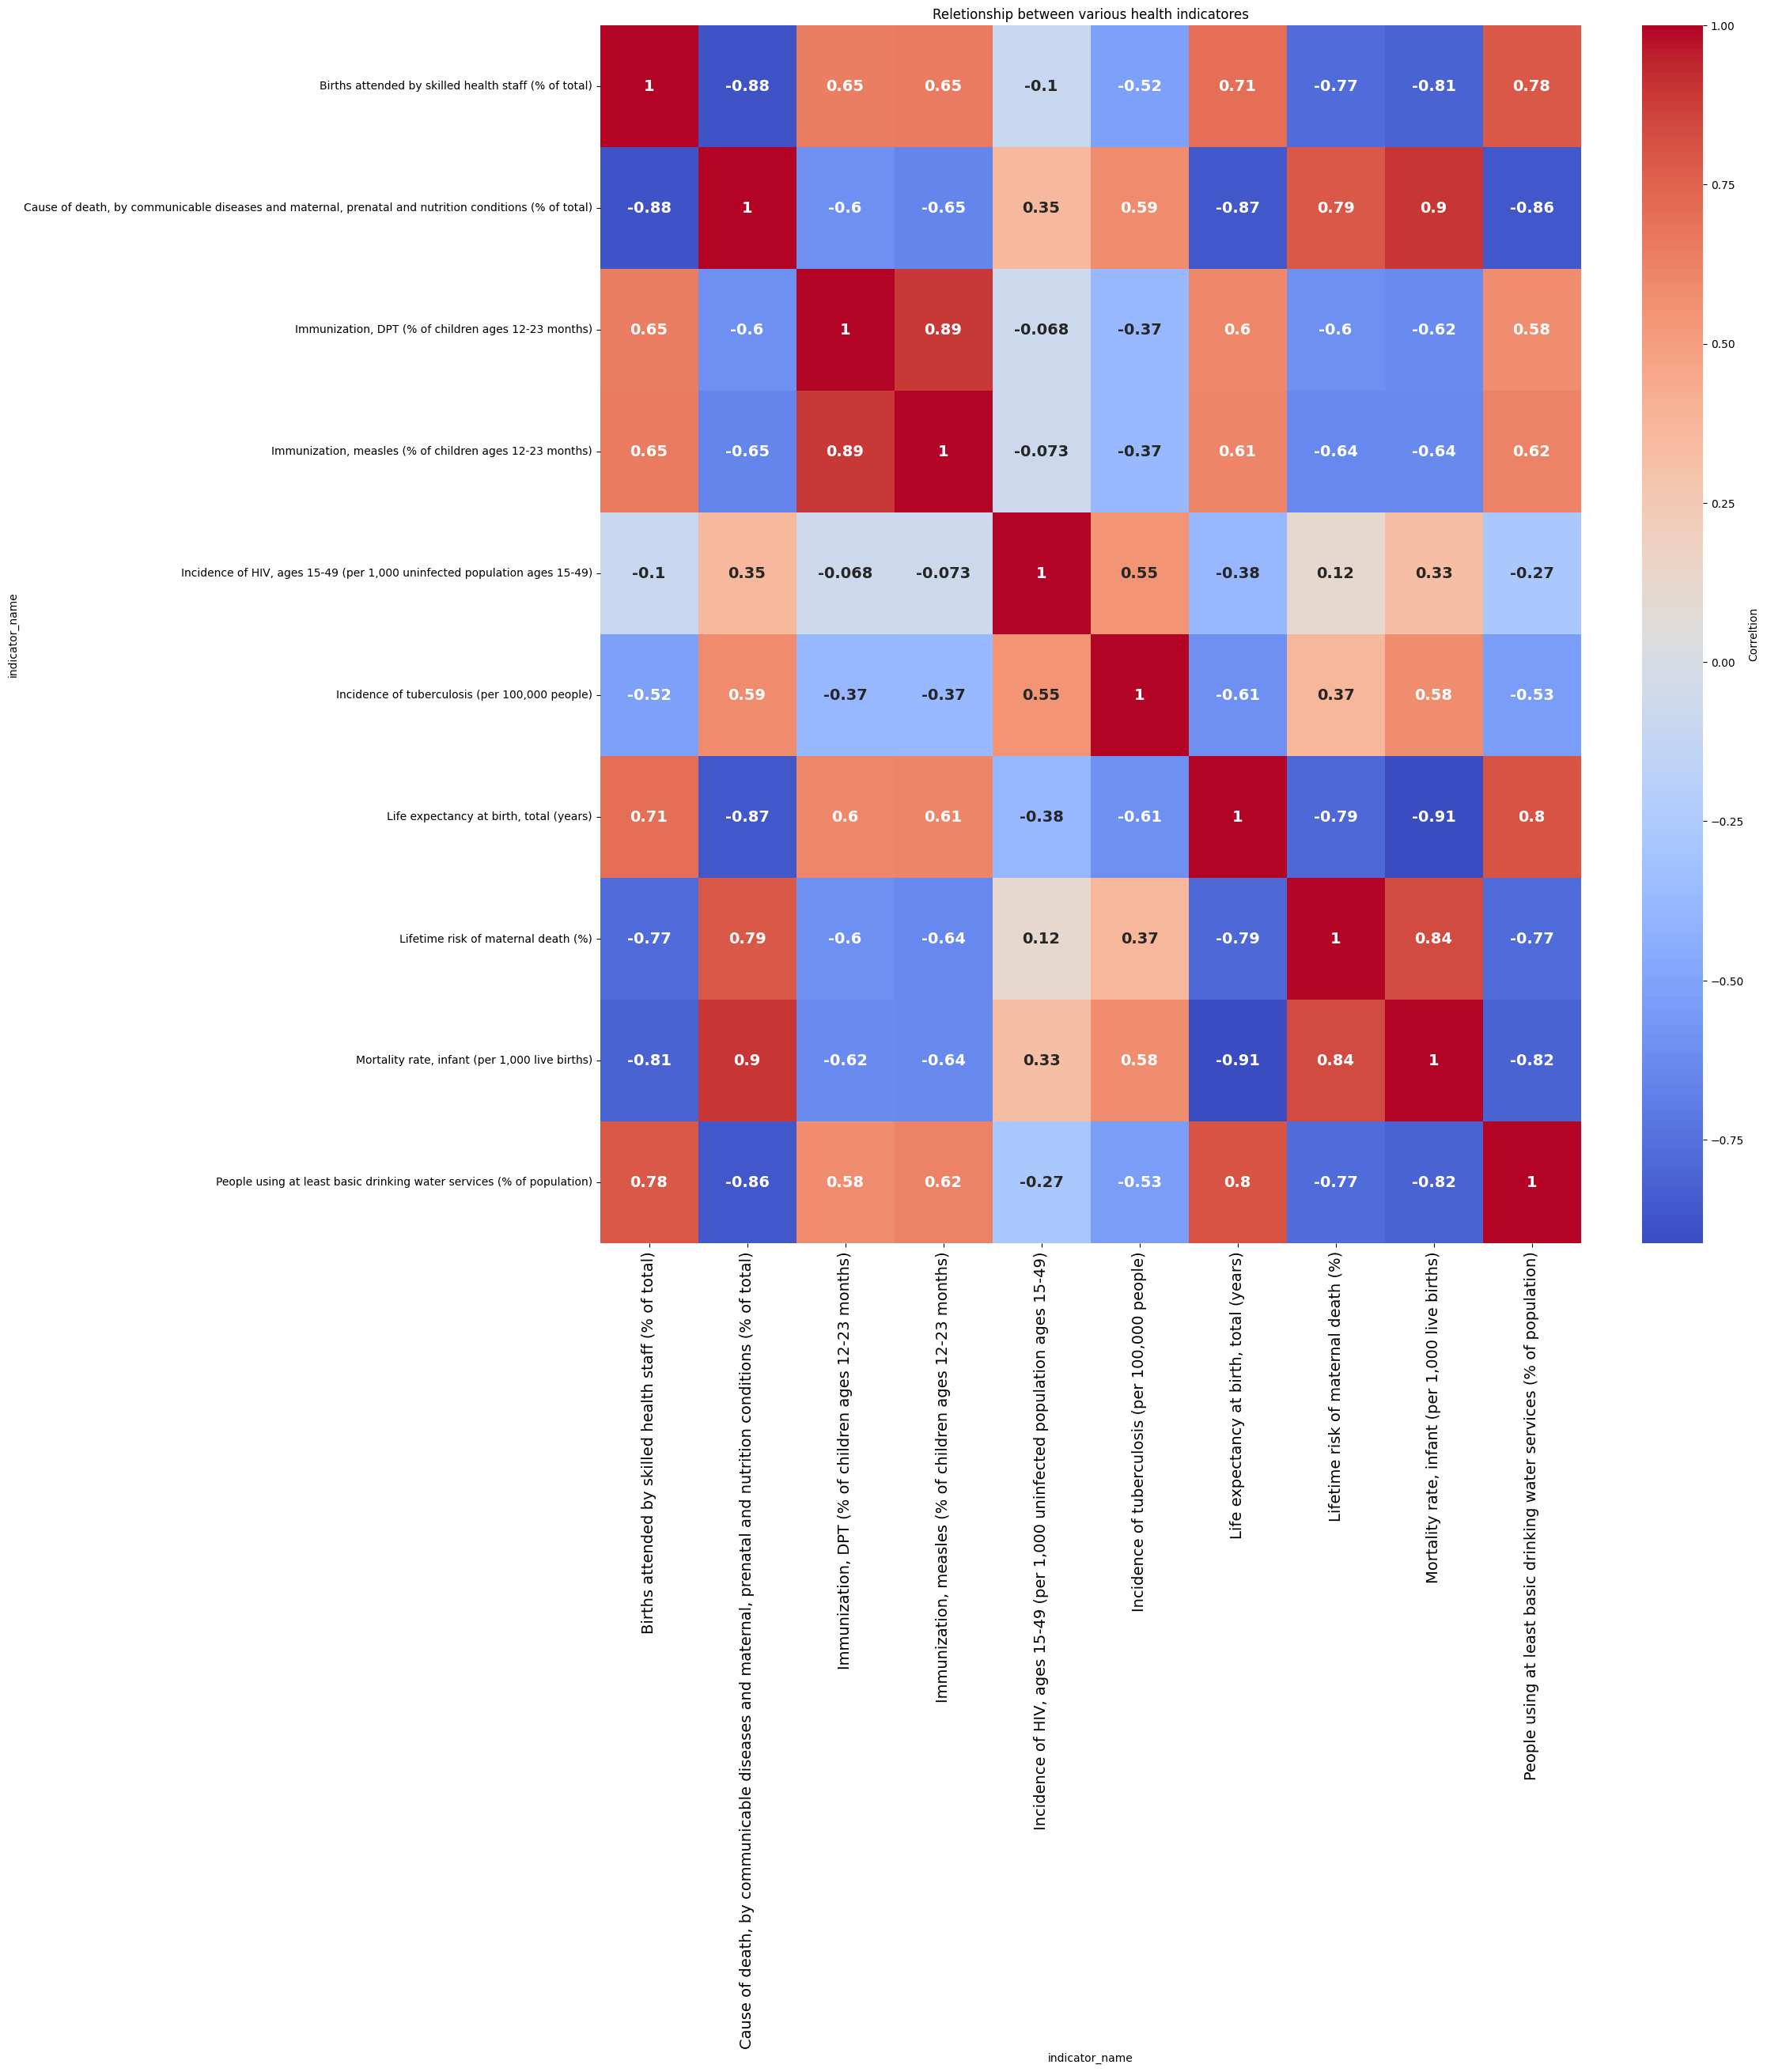

In [39]:
df_wide = health.pivot_table(index=["country_value","year"],
                             columns="indicator_name",
                             values="value"
                            )
corr = df_wide.corr()
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize =(20,20), facecolor = "none")
ax= sns.heatmap(
    corr,
    annot = True,
    cmap= "coolwarm",
    cbar_kws= {"label":"Correltion"},
    annot_kws = {"fontsize":14, "fontweight":"bold"}
)

plt.title("Reletionship between various health indicatores")
ax.tick_params(axis="x",labelsize = 14)
ax.tick_params(axis="x",labelsize = 14)
plt.show()
               

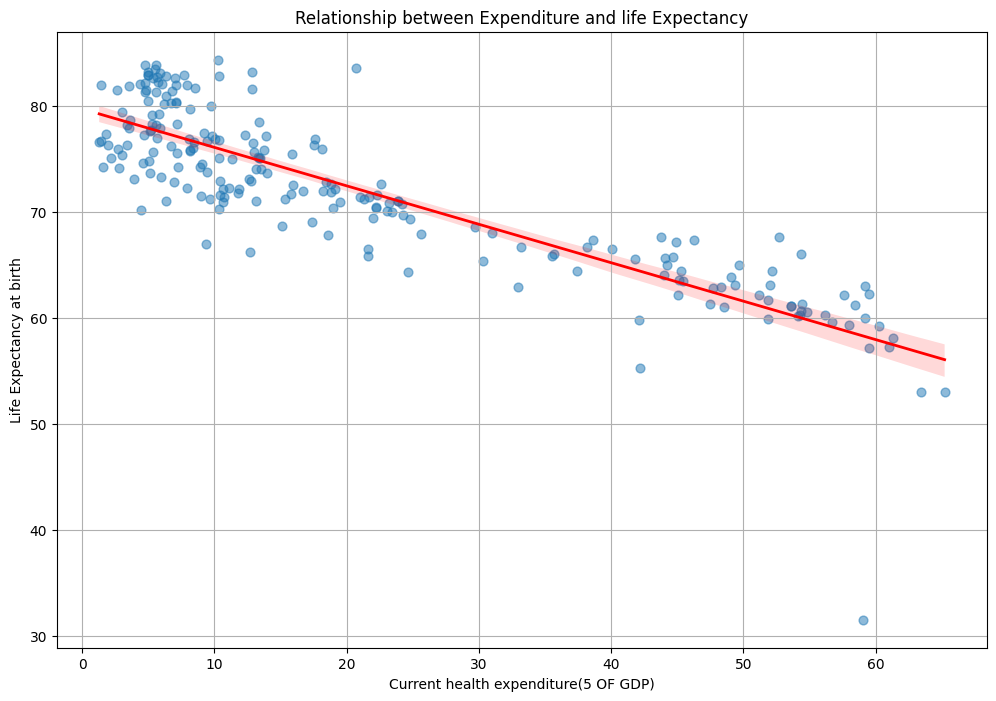

In [42]:
df_pivot = health.pivot(index=["country_value","year"],
                             columns="indicator_name",
                             values="value"
                            ).reset_index()
plt.figure(figsize=(12,8),facecolor="none")

ax=sns.regplot(data=df_pivot,
               x="Cause of death, by communicable diseases and maternal, prenatal and nutrition conditions (% of total)",
               y="Life expectancy at birth, total (years)",
               scatter_kws={"alpha":0.5,"s":40},
               line_kws = {"color":"red","lw":2}
              )

plt.title("Relationship between Expenditure and life Expectancy")
plt.xlabel("Current health expenditure(5 OF GDP)")
plt.ylabel("Life Expectancy at birth")
plt.grid(True)
plt.show()
               

In [41]:
df_pivot

indicator_name,country_value,year,Births attended by skilled health staff (% of total),"Cause of death, by communicable diseases and maternal, prenatal and nutrition conditions (% of total)","Immunization, DPT (% of children ages 12-23 months)","Immunization, measles (% of children ages 12-23 months)","Incidence of HIV, ages 15-49 (per 1,000 uninfected population ages 15-49)","Incidence of tuberculosis (per 100,000 people)","Life expectancy at birth, total (years)",Lifetime risk of maternal death (%),"Mortality rate, infant (per 1,000 live births)",People using at least basic drinking water services (% of population)
0,Afghanistan,2016,NaN,NaN,66.0,64.0,0.1,204.0,62.646,3.775891,62.3,62.822070
1,Afghanistan,2017,53.4,NaN,64.0,64.0,0.1,209.0,62.406,3.469739,60.4,65.142136
2,Afghanistan,2018,58.8,NaN,68.0,66.0,0.1,212.0,62.443,3.246425,58.6,67.475869
3,Afghanistan,2019,NaN,32.930451,65.0,57.0,0.1,213.0,62.941,3.042626,56.9,69.822698
4,Afghanistan,2020,61.8,NaN,61.0,57.0,0.1,205.0,61.454,3.135944,55.3,72.182071
...,...,...,...,...,...,...,...,...,...,...,...,...
2123,Zimbabwe,2019,NaN,NaN,90.0,85.0,2.3,199.0,61.060,1.438150,46.0,67.179593
2124,Zimbabwe,2020,NaN,NaN,86.0,85.0,1.9,189.0,61.530,1.407570,44.9,67.166424
2125,Zimbabwe,2021,NaN,NaN,88.0,88.0,2.2,198.0,60.135,1.632553,43.6,67.162605
2126,Zimbabwe,2022,NaN,NaN,90.0,90.0,1.6,209.0,62.360,1.346997,42.2,67.168908
